# Notebook 3 — Exploratory Data Analysis (EDA)
**Input:** `data/processed/gtd_cleaned.csv`  
**Goal:** Explore distributions, trends, and relationships across all key columns.

### Imports
Loads data manipulation and visualisation libraries. Sets a consistent plot style throughout the notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load Data

### Read Cleaned CSV
Loads the fully cleaned dataset produced by Notebook 2 and prints its shape.

In [2]:
df = pd.read_csv('../data/processed/gtd_cleaned.csv')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 34,268 rows × 9 columns


,Year,Month,Duration,Country,Region,City,Crime,Reason,Individual
0,1970,1,0,United States,North America,Cairo,1,To protest the Cairo Illinois Police Deparment,0
1,1970,1,0,United States,North America,Madison,1,To protest the War in Vietnam and the draft,0
2,1970,1,0,United States,North America,Madison,1,To protest the War in Vietnam and the draft,0
3,1970,1,0,United States,North America,Denver,1,Protest the draft and Vietnam War,0
4,1970,1,0,United States,North America,Rio Piedras,1,To protest United States owned businesses in P...,0


## 2. Dataset Overview

### Basic Info & Statistics
Prints data types, null counts, and descriptive statistics to confirm the dataset is clean before analysis.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34268 entries, 0 to 34267
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Year        34268 non-null  int64
 1   Month       34268 non-null  int64
 2   Duration    34268 non-null  int64
 3   Country     34268 non-null  str  
 4   Region      34268 non-null  str  
 5   City        34268 non-null  str  
 6   Crime       34268 non-null  int64
 7   Reason      34268 non-null  str  
 8   Individual  34268 non-null  int64
dtypes: int64(5), str(4)
memory usage: 7.1 MB


In [4]:
df.describe(include='all')

,Year,Month,Duration,Country,Region,City,Crime,Reason,Individual
count,34268.000000,34268.000000,34268.000000,34268,34268,34268,34268.000000,34268,34268.000000
unique,NaN,NaN,NaN,154,12,10836,NaN,13916,NaN
top,NaN,NaN,NaN,Iraq,South Asia,Baghdad,NaN,The specific motive for the attack is unknown.,NaN
freq,NaN,NaN,NaN,6320,12491,2434,NaN,13937,NaN
mean,2009.616844,6.490166,0.077157,NaN,NaN,NaN,0.986343,NaN,0.010622
std,6.648711,3.355954,0.266844,NaN,NaN,NaN,0.116064,NaN,0.102516
min,1970.000000,1.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,0.000000
25%,2008.000000,4.000000,0.000000,NaN,NaN,NaN,1.000000,NaN,0.000000
50%,2010.000000,7.000000,0.000000,NaN,NaN,NaN,1.000000,NaN,0.000000
75%,2013.000000,9.000000,0.000000,NaN,NaN,NaN,1.000000,NaN,0.000000


## 3. Temporal Analysis

### Attacks Per Year
Line chart showing the number of terrorist incidents per year. Reveals long-term trends and spikes in activity.

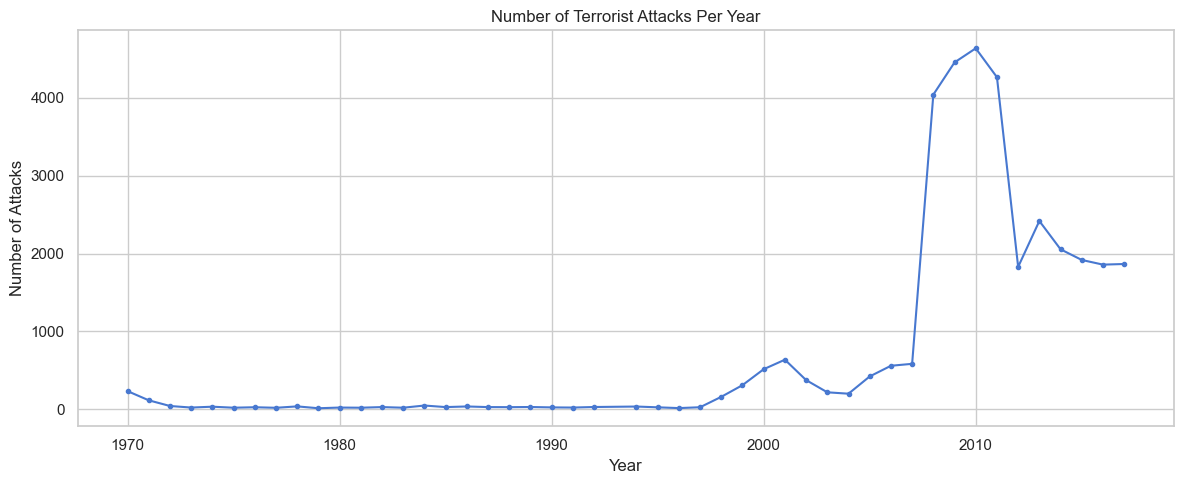

In [5]:
yearly = df['Year'].value_counts().sort_index()

plt.figure()
plt.plot(yearly.index, yearly.values, marker='o', linewidth=1.5, markersize=3)
plt.title('Number of Terrorist Attacks Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.tight_layout()
plt.show()

### Attacks Per Month
Bar chart showing the distribution of attacks across the 12 months. Identifies any seasonal patterns.

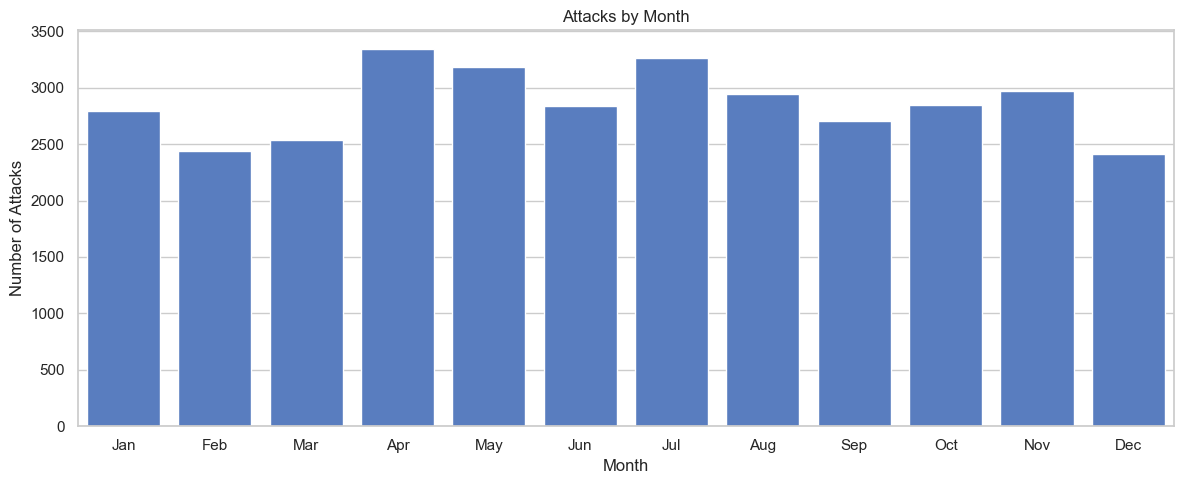

In [6]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df['Month'].value_counts().sort_index()

plt.figure()
sns.barplot(x=monthly.index, y=monthly.values)
plt.xticks(ticks=range(12), labels=month_labels)
plt.title('Attacks by Month')
plt.xlabel('Month')
plt.ylabel('Number of Attacks')
plt.tight_layout()
plt.show()

## 4. Geographic Analysis

### Top 10 Countries by Attacks
Horizontal bar chart of the 10 countries with the most recorded incidents.

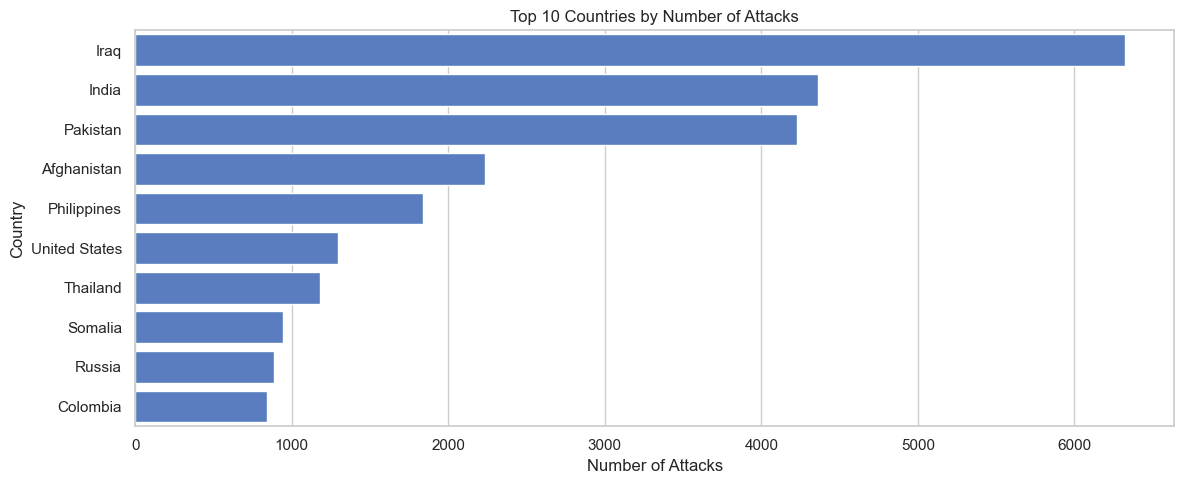

In [7]:
top_countries = df['Country'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Number of Attacks')
plt.xlabel('Number of Attacks')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Attacks by Region
Bar chart showing total attacks per world region, sorted by frequency.

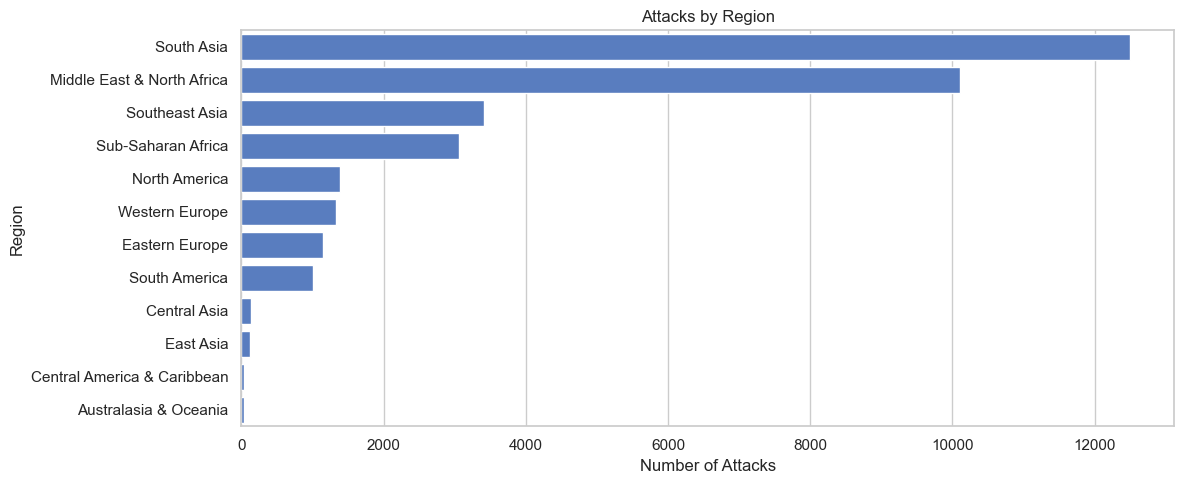

In [8]:
region_counts = df['Region'].value_counts()

plt.figure()
sns.barplot(x=region_counts.values, y=region_counts.index)
plt.title('Attacks by Region')
plt.xlabel('Number of Attacks')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

### Top 10 Cities by Attacks
Horizontal bar chart of the 10 most targeted cities.

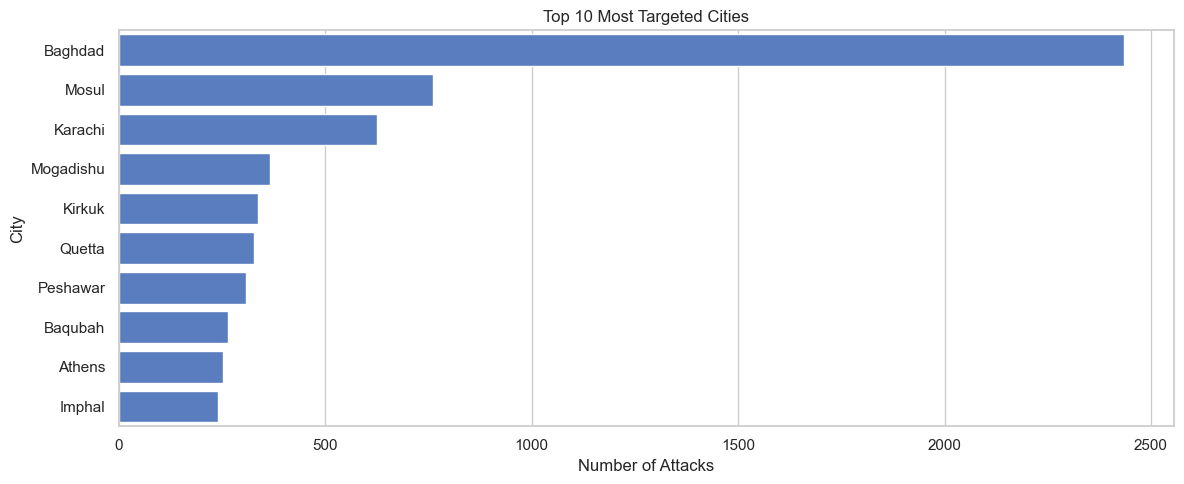

In [9]:
top_cities = df['City'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title('Top 10 Most Targeted Cities')
plt.xlabel('Number of Attacks')
plt.ylabel('City')
plt.tight_layout()
plt.show()

## 5. Attack Characteristics

### Duration Distribution
Pie chart showing the proportion of attacks that lasted more than 24 hours (Duration=1) vs those that did not (Duration=0).

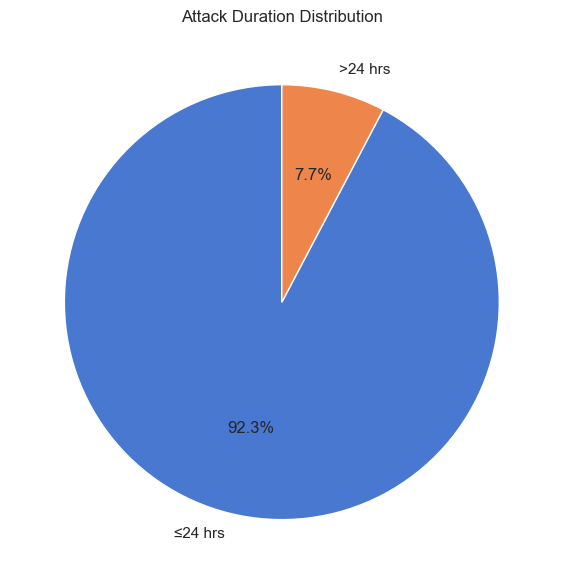

In [10]:
duration_counts = df['Duration'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    duration_counts.values,
    labels=['≤24 hrs', '>24 hrs'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('muted', 2)
)
plt.title('Attack Duration Distribution')
plt.tight_layout()
plt.show()

### Crime Flag Distribution
Pie chart showing the proportion of attacks classified as criminal (Crime=1) vs non-criminal (Crime=0).

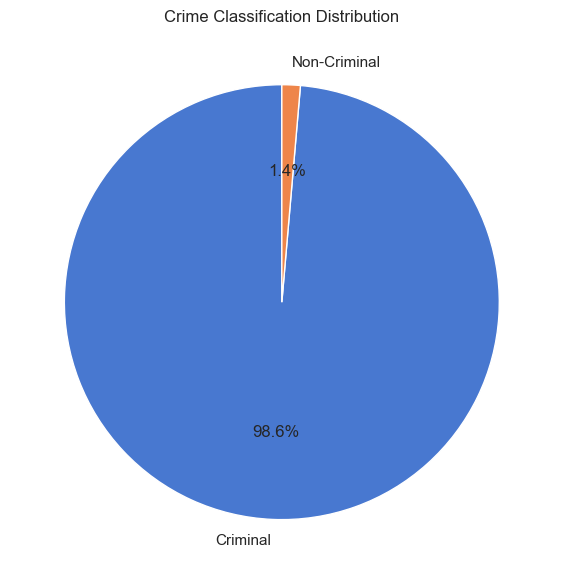

In [11]:
crime_counts = df['Crime'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    crime_counts.values,
    labels=['Criminal', 'Non-Criminal'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('muted', 2)
)
plt.title('Crime Classification Distribution')
plt.tight_layout()
plt.show()

### Individual vs Group Attacks
Pie chart showing the proportion of attacks carried out by individuals (Individual=1) vs organised groups (Individual=0).

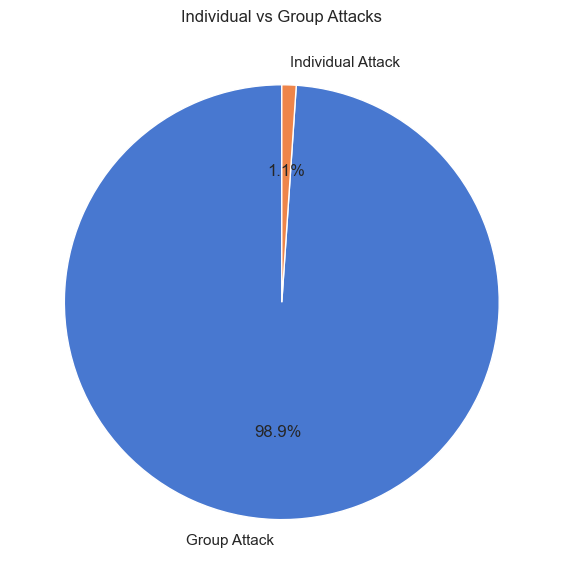

In [12]:
ind_counts = df['Individual'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    ind_counts.values,
    labels=['Group Attack', 'Individual Attack'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('muted', 2)
)
plt.title('Individual vs Group Attacks')
plt.tight_layout()
plt.show()

## 6. Trend Analysis

### Attacks Over Time by Region
Line chart showing how attack counts per region have changed over the years. Highlights which regions drove the overall increase.

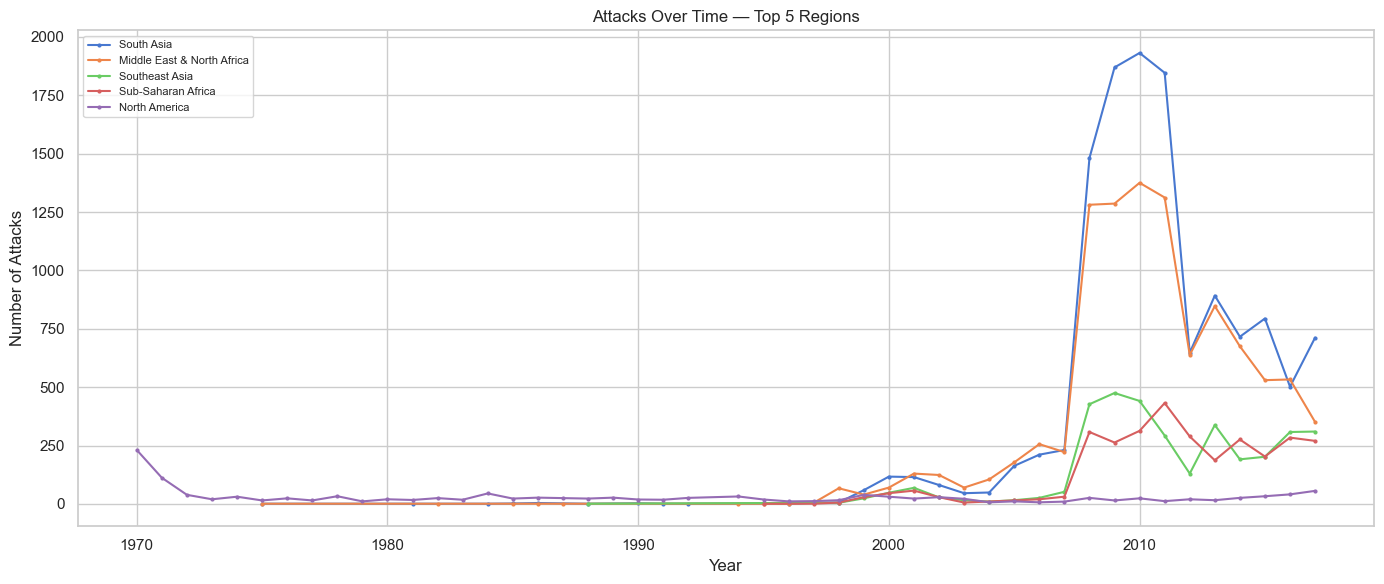

In [13]:
top_regions = df['Region'].value_counts().head(5).index
region_year = df[df['Region'].isin(top_regions)].groupby(['Year', 'Region']).size().reset_index(name='Count')

plt.figure(figsize=(14, 6))
for region in top_regions:
    data = region_year[region_year['Region'] == region]
    plt.plot(data['Year'], data['Count'], marker='o', markersize=2, linewidth=1.5, label=region)

plt.title('Attacks Over Time — Top 5 Regions')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Duration Trend Over Years
Stacked bar chart showing the proportion of short vs extended attacks per year.

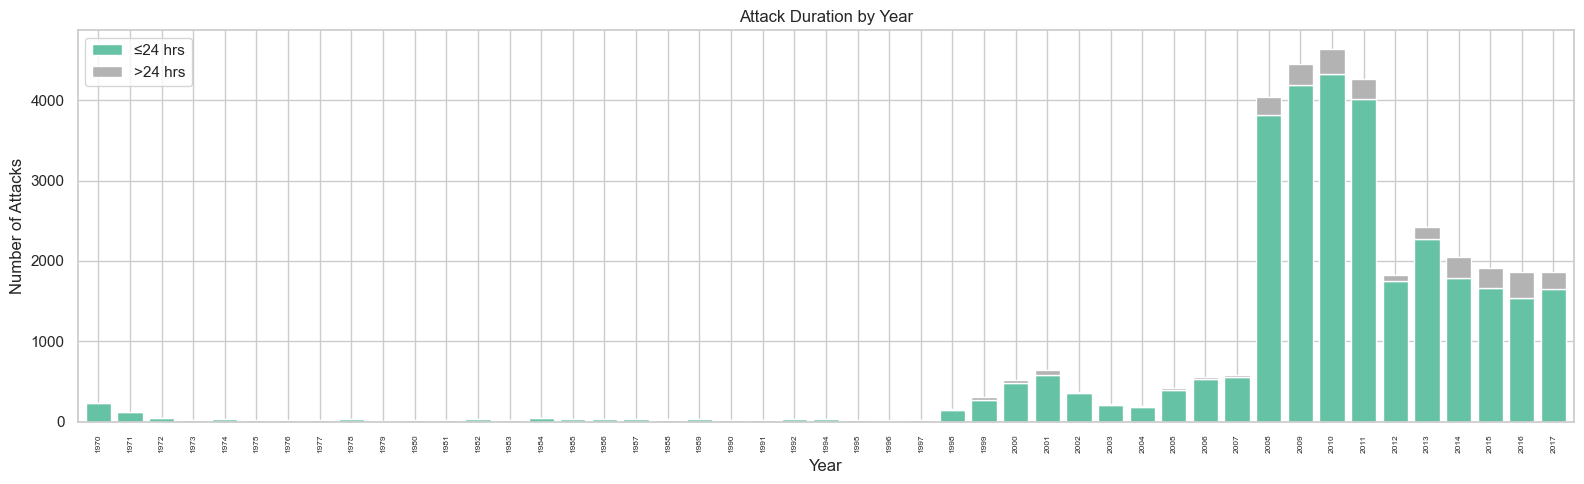

In [14]:
dur_year = df.groupby(['Year', 'Duration']).size().unstack(fill_value=0)
dur_year.columns = ['≤24 hrs', '>24 hrs']

dur_year.plot(kind='bar', stacked=True, figsize=(16, 5), colormap='Set2', width=0.8)
plt.title('Attack Duration by Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=90, fontsize=6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 7. Correlation & Heatmap

### Correlation Heatmap
Heatmap of correlations between all numeric columns. Helps identify any linear relationships between Year, Month, Duration, Crime, and Individual.

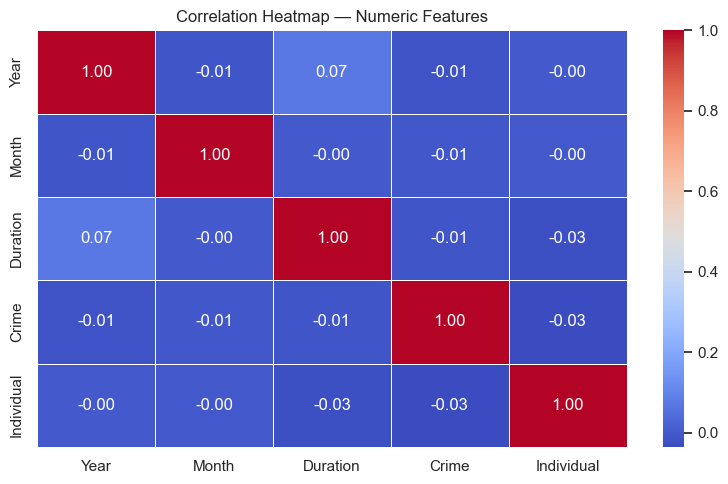

In [15]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    df[['Year', 'Month', 'Duration', 'Crime', 'Individual']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5
)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

## 8. Summary Statistics

### Key Counts
Prints a concise summary of the most important counts from the EDA.

In [16]:
print(f"Total incidents       : {len(df):,}")
print(f"Year range            : {df['Year'].min()} – {df['Year'].max()}")
print(f"Unique countries      : {df['Country'].nunique()}")
print(f"Unique regions        : {df['Region'].nunique()}")
print(f"Unique cities         : {df['City'].nunique()}")
print(f"Extended attacks (>24h): {(df['Duration']==1).sum():,} ({(df['Duration']==1).mean()*100:.1f}%)")
print(f"Individual attacks    : {(df['Individual']==1).sum():,} ({(df['Individual']==1).mean()*100:.1f}%)")
print(f"Criminal attacks      : {(df['Crime']==1).sum():,} ({(df['Crime']==1).mean()*100:.1f}%)")

Total incidents       : 34,268
Year range            : 1970 – 2017
Unique countries      : 154
Unique regions        : 12
Unique cities         : 10836
Extended attacks (>24h): 2,644 (7.7%)
Individual attacks    : 364 (1.1%)
Criminal attacks      : 33,800 (98.6%)
